In [1]:
import os
import math
import json
import random
import pandas as pd
import numpy as np
import scipy as sp
import pylab as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


import jupyter_black

jupyter_black.load()

%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [2]:
VERSION = "research-article_aimrd_f"
BASELINE = "baseline_2026-01-23"
RESULTS_PATH = os.path.join("../../data/results/", BASELINE, VERSION)
start_date = "11-2017"
end_date = "12-2025"
vocab_version = ""

os.makedirs(os.path.join("../results/plots", VERSION), exist_ok=True)

months = np.arange(1, 13)
years = np.arange(2000, 2026)
months_w_years = [f"{m}-{y}" for y in years for m in months]

with open(os.path.join(RESULTS_PATH, "filters.json")) as f:
    filters = json.load(f)
dates = pd.to_datetime(filters["all_dates"])

sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

totals_m, totals_y = utils.get_totals(RESULTS_PATH, start_date, end_date)

In [3]:
def proj_single_word(freqs_df, totals_m, start_date="11-2017"):
    start_split = start_date.split("-")
    end_split = freqs_df.columns[-1].split("-")
    x_months = np.arange(
        int(start_split[1]) + ((int(start_split[0]) - 1) / 12),
        int(end_split[1]) + ((int(end_split[0]) - 1) / 12),
        1 / 12,
    )
    freqs, proj, ratios, diffs, sdev = utils.frequency_projection(freqs_df, 60)
    usage = diffs / (1 - proj)
    df = pd.DataFrame(
        zip(x_months, freqs[0], proj[0], diffs[0], ratios[0], usage[0], sdev[0]),
        columns=["time", "frequency", "projection", "diff", "ratio", "usage", "sdev"],
    )
    n_m = [totals_m[math.floor(y)][round((y % 1) * 12)] for y in df["time"]]
    df["regression se (ds)"] = list(
        map(
            utils.se,
            df["projection"],
            df["frequency"],
            n_m,
            ["regression"] * len(df),
            df["sdev"],
        )
    )
    return df

In [4]:
sec = "abstract"

freqs_df = pd.read_csv(
    os.path.join(RESULTS_PATH, sec, "freqs_df.csv.gz"),
    compression="gzip",
    index_col=0,
).reset_index()

#### Preparation Panel a

In [5]:
excess_df = freqs_df[
    freqs_df["index"].apply(lambda x: x in utils.excess_style_words_2024)
]

In [6]:
excess_df

,index,1-2000,2-2000,3-2000,4-2000,5-2000,6-2000,7-2000,8-2000,9-2000,...,3-2025,4-2025,5-2025,6-2025,7-2025,8-2025,9-2025,10-2025,11-2025,12-2025
1262,accentuates,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,...,0.000144,0.000073,0.000070,0.000157,0.000062,0.000148,0.000160,0.000075,0.000078,0.000191
1934,achieving,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,...,0.021553,0.019856,0.021517,0.018259,0.024504,0.026392,0.023326,0.024852,0.023227,0.025172
2178,acknowledges,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,...,0.000216,0.000145,0.000070,0.000078,0.000062,0.000074,0.000240,0.000225,0.000156,0.000096
2179,acknowledging,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,...,0.000718,0.000509,0.000421,0.000392,0.000677,0.000593,0.000639,0.000901,0.000701,0.000670
2505,across,0.011628,0.042254,0.033333,0.025641,0.020408,0.024390,0.074074,0.025641,0.063830,...,0.151735,0.149174,0.162742,0.172714,0.178611,0.180666,0.193881,0.195886,0.213406,0.210184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284018,versatility,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,...,0.002083,0.002691,0.002313,0.002664,0.003017,0.002965,0.003116,0.002252,0.002416,0.003158
287363,warranting,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,...,0.002443,0.003273,0.003084,0.002899,0.003140,0.004003,0.003116,0.003979,0.004053,0.003733
288559,while,0.104651,0.098592,0.144444,0.076923,0.061224,0.097561,0.111111,0.051282,0.085106,...,0.228752,0.232962,0.242921,0.239950,0.241719,0.254652,0.265777,0.262182,0.266563,0.281202
289316,within,0.116279,0.169014,0.144444,0.115385,0.153061,0.158537,0.074074,0.115385,0.202128,...,0.138588,0.140374,0.147042,0.154220,0.144563,0.149974,0.150983,0.147984,0.155027,0.153044


In [7]:
len(utils.excess_style_words_2024)

379

In [8]:
# Columns belonging to each year
cols_2022 = [c for c in excess_df.columns if c.endswith("-2022")]
cols_2024 = [c for c in excess_df.columns if c.endswith("-2024")]
cols_2025 = [c for c in excess_df.columns if c.endswith("-2025")]

# Create a new dataframe with yearly averages
df_22_25 = pd.DataFrame(
    {
        "word": excess_df["index"],
        "avg_2022": excess_df[cols_2022].mean(axis=1),
        "avg_2024": excess_df[cols_2024].mean(axis=1),
        "avg_2025": excess_df[cols_2025].mean(axis=1),
    }
)

In [9]:
df_22_25["ratio22-24"] = df_22_25["avg_2024"] / df_22_25["avg_2022"]
df_22_25[df_22_25["ratio22-24"] > 5]

,word,avg_2022,avg_2024,avg_2025,ratio22-24
4212,advancements,0.001013,0.005122,0.006142,5.056329
64019,delved,0.000099,0.000730,0.000342,7.347939
64020,delves,0.000113,0.000999,0.000355,8.875161
129972,intricate,0.001528,0.008571,0.006015,5.610610
158965,meticulously,0.000145,0.001066,0.000579,7.364079
244882,showcasing,0.000171,0.001432,0.001088,8.364724
259609,surpassing,0.000381,0.002237,0.002767,5.872305
278672,underscore,0.002237,0.014057,0.024977,6.282722
278674,underscores,0.001457,0.011184,0.014762,7.674187
278675,underscoring,0.001163,0.006261,0.014561,5.381556


In [10]:
df_22_25[df_22_25["word"].apply(lambda x: "delv" in x)]

,word,avg_2022,avg_2024,avg_2025,ratio22-24
64018,delve,0.000187,0.000878,0.000498,4.696145
64019,delved,0.000099,0.000730,0.000342,7.347939
64020,delves,0.000113,0.000999,0.000355,8.875161
64023,delving,0.000094,0.000237,0.000192,2.508845


#### Preparation panel b - d

In [11]:
selection = ["these", "delves", "potential"]
proj_dict = {}
for w in selection:
    freqs_df_word = freqs_df[freqs_df["index"] == w].drop(["index"], axis=1)
    proj_dict[w] = proj_single_word(freqs_df_word, totals_m)

1it [00:00, 204.93it/s]
1it [00:00, 381.68it/s]
1it [00:00, 381.89it/s]


In [12]:
proj_dict["these"]

,time,frequency,projection,diff,ratio,usage,sdev,regression se (ds)
0,2017.833333,0.394406,0.392927,0.001479,1.003763,0.002436,0.005449,0.012640
1,2017.916667,0.392680,0.392330,0.000350,1.000892,0.000576,0.005441,0.012490
2,2018.000000,0.388438,0.391733,-0.003295,0.991588,-0.005417,0.005433,0.012738
3,2018.083333,0.399295,0.391136,0.008159,1.020861,0.013401,0.005425,0.012433
4,2018.166667,0.386820,0.390538,-0.003718,0.990479,-0.006101,0.005418,0.012664
...,...,...,...,...,...,...,...,...
93,2025.583333,0.479205,0.337382,0.141824,1.420366,0.214035,0.005882,0.009147
94,2025.666667,0.490813,0.336784,0.154029,1.457352,0.232246,0.005899,0.009421
95,2025.750000,0.485922,0.336187,0.149735,1.445393,0.225568,0.005916,0.009639
96,2025.833333,0.501559,0.335590,0.165969,1.494559,0.249799,0.005933,0.009349


#### Preparation panel e 

In [13]:
### getting set of 100 low-frequency excess words with freqs, proj, etc.

X = sp.sparse.load_npz(os.path.join(RESULTS_PATH, sec, f"count_{sec}.pkl.npz"))

words = np.load(
    os.path.join(RESULTS_PATH, sec, f"words_{sec}.pkl.npy"), allow_pickle=True
)

ind_words = np.isin(words, utils.excess_style_words_2024)
ind = dates.year == 2024

counts = np.array(np.sum(X[ind, :][:, ind_words], axis=0)).ravel()
totals = np.sum(ind)
freqs_2024 = (counts + 1) / (totals + 1)

In [14]:
# cutoff for 100 words at 0.000775
# cutoff for 200 words at 0.0038
ind_excess = freqs_2024 < 0.0038
excess_words_cutoff = words[ind_words][ind_excess]
len(excess_words_cutoff)

200

In [15]:
# index of word selection
ind_words_cutoff = np.isin(words, excess_words_cutoff)

group_counts = np.zeros(12 * years.size)
group_totals = np.zeros(12 * years.size)

for j, year in enumerate(years):
    for i, month in enumerate(months):
        ind = (dates.month == month) & (dates.year == year)

        group_counts[12 * j + i] = np.sum(
            np.sum(X[ind, :][:, ind_words_cutoff], axis=1) > 0
        )
        # count papers per month
        group_totals[12 * j + i] = np.sum(ind)

freqs = (group_counts + 1) / (group_totals + 1)
group_freqs_df = pd.DataFrame(
    dict(zip(months_w_years, list(freqs.T))), index=["excess_words"]
)

In [16]:
proj_dict["excess_list"] = proj_single_word(group_freqs_df, totals_m)

1it [00:00, 259.76it/s]


In [17]:
proj_dict["excess_list"]

,time,frequency,projection,diff,ratio,usage,sdev,regression se (ds)
0,2017.833333,0.068046,0.068757,-0.000711,0.989657,-0.000764,0.003330,0.004667
1,2017.916667,0.067099,0.069043,-0.001944,0.971843,-0.002088,0.003325,0.004615
2,2018.000000,0.071667,0.069329,0.002339,1.033732,0.002513,0.003320,0.004735
3,2018.083333,0.071752,0.069615,0.002137,1.030702,0.002297,0.003315,0.004672
4,2018.166667,0.061185,0.069901,-0.008716,0.875310,-0.009371,0.003310,0.004612
...,...,...,...,...,...,...,...,...
93,2025.583333,0.202387,0.095360,0.107027,2.122351,0.118309,0.003594,0.004941
94,2025.666667,0.198354,0.095646,0.102708,2.073840,0.113571,0.003604,0.005186
95,2025.750000,0.199114,0.095932,0.103182,2.075575,0.114131,0.003614,0.005304
96,2025.833333,0.207093,0.096218,0.110875,2.152327,0.122679,0.003625,0.005242


In [18]:
proj_dict.keys()

dict_keys(['these', 'delves', 'potential', 'excess_list'])

#### Preparation panel f-g

In [19]:
excess_words = utils.excess_style_words_2024
cutoffs = [
    0.0002,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
    0.02,
    0.03,
    0.04,
    0.05,
    0.07,
    0.1,
    0.15,
    0.2,
    0.3,
    0.4,
    0.5,
    0.7,
    1.0,
]

In [20]:
excess_words_cutoff = {}
cutoff_counts = np.zeros((1, len(cutoffs)), dtype=int)

# X and words already loaded, if not add here

ind_words = np.isin(words, excess_words)
ind = dates.year == 2024

counts = np.array(np.sum(X[ind, :][:, ind_words], axis=0)).ravel()
totals = np.sum(ind)

freqs_2024 = (counts + 1) / (totals + 1)

for j, cutoff in enumerate(cutoffs):

    ind_excess = freqs_2024 < cutoff

    cutoff_counts[0, j] = np.sum(ind_excess)
    excess_words_cutoff[cutoff] = words[ind_words][ind_excess]


totals_yearly = {}
for year in range(2018, 2026):
    totals_yearly[year] = np.sum(dates.year == year)


pd.DataFrame(cutoff_counts, columns=cutoffs, index=["abstract"])

,0.0002,0.0005,0.0010,0.0020,0.0050,0.0100,0.0200,0.0300,0.0400,0.0500,0.0700,0.1000,0.1500,0.2000,0.3000,0.4000,0.5000,0.7000,1.0000
abstract,25,66,122,166,224,252,294,312,323,332,343,355,365,371,376,378,378,379,379


In [21]:
freqs_cutoffs = utils.get_cutoff_frequency(
    RESULTS_PATH,
    sec,
    excess_words_cutoff,
    lemmatized="_non-lemmatized",
)

totals = [totals_yearly[y] for y in freqs_cutoffs["time"]]

p = freqs_cutoffs["projection"]
q = freqs_cutoffs["frequency"]
reg_se = freqs_cutoffs["regression se"]
freqs_cutoffs["binomial se"] = list(map(lambda p, n: p * (1 - p) / n, p, totals))
freqs_cutoffs["binomial se (ds)"] = list(
    map(utils.se, p, q, totals, ["binomial"] * len(p))
)
freqs_cutoffs["regression se (ds)"] = list(
    map(utils.se, p, q, totals, ["regression"] * len(p), reg_se)
)
freqs_cutoffs["combined se (ds)"] = list(
    map(utils.se, p, q, totals, ["both"] * len(p), reg_se)
)
freqs_cutoffs["regression se (delta)"] = list(
    map(utils.se, p, q, totals, ["regression"] * len(p), reg_se, ["delta"] * len(p))
)

# filter out cutoffs with too high base frequency
remove = freqs_cutoffs[freqs_cutoffs["projection"] >= 0.999]["cutoff"].unique()
freqs_cutoffs_filtered = freqs_cutoffs[
    freqs_cutoffs["cutoff"].apply(lambda x: x not in remove)
].copy()

loading cutoff freqs


#### Preparation panel h

In [22]:
def delta_f(x: float) -> float:
    # should d also depend on x, but inversely? more variation for smaller freqs
    d = random.uniform(0.5, 5)
    d = x * d
    if d + x <= 1:
        return d
    else:
        return delta_f(x)


def se(p: float, q: float, n: int):
    # this should be replaced with utils.se
    if p >= 1.0:
        p = 0.9999999999999999
    if q == 1.0:
        q = 0.9999999999999999
    var = (p * (1 - p) * (q - 1) ** 2) / ((1 - p) ** 4 * n) + (q * (1 - q)) / (
        (1 - p) ** 2 * n
    )
    return math.sqrt(var)

In [23]:
n_words = 500
n_texts = 100000
random.seed(0)
rng = np.random.default_rng(seed=0)

gamma_shape = 2
gamma_scale = 0.02
p = rng.gamma(shape=gamma_shape, scale=gamma_scale, size=n_words)
delta = list(map(delta_f, p))
q = p + delta

llm_use = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
X_before = {}
X_after = {}
counts_before = {}
counts_after = {}
freqs_before = {}
freqs_after = {}

for l in llm_use:
    X_b = np.zeros((n_words, n_texts))
    X_a = np.zeros((n_words, n_texts))
    k = int(l * n_texts)
    for i in range(n_words):
        X_b[i, :] = rng.binomial(1, p[i], n_texts)
        X_a[i, k:] = rng.binomial(1, p[i], n_texts - k)
        X_a[i, :k] = rng.binomial(1, q[i], k)
    X_before[l] = X_b
    X_after[l] = X_a

    counts_before[l] = np.sum(X_b, axis=1)
    counts_after[l] = np.sum(X_a, axis=1)

    freqs_before[l] = (counts_before[l] + 1) / (n_texts + 1)
    freqs_after[l] = (counts_after[l] + 1) / (n_texts + 1)

group_freqs_before = {}
group_freqs_after = {}
diff = {}
low_bound = {}
ses = {}

for l in llm_use:

    group_freqs_b = np.zeros(len(cutoffs))
    group_freqs_a = np.zeros(len(cutoffs))

    for i, cutoff in enumerate(cutoffs):

        ind = freqs_before[l] < cutoff
        group_counts_b = np.sum(np.sum(X_before[l][ind, :], axis=0) > 0)
        group_counts_a = np.sum(np.sum(X_after[l][ind, :], axis=0) > 0)
        group_freqs_b[i] = (group_counts_b + 1) / (n_texts + 1)
        group_freqs_a[i] = (group_counts_a + 1) / (n_texts + 1)

    group_freqs_before[l] = group_freqs_b
    group_freqs_after[l] = group_freqs_a
    diff[l] = group_freqs_a - group_freqs_b
    low_bound[l] = diff[l] / (1 - group_freqs_b)
    # low_bound[l] = np.nan_to_num(low)
    ses[l] = list(map(se, group_freqs_b, group_freqs_a, [n_texts] * len(group_freqs_a)))

dfs = {}
dfs_filt = {}
for l in llm_use:
    dfs[l] = pd.DataFrame(
        zip(
            cutoffs,
            group_freqs_before[l],
            group_freqs_after[l],
            diff[l],
            low_bound[l],
            ses[l],
        ),
        columns=["cutoff", "p", "q", "diff", "usage", "sdev"],
    )
    dfs_filt[l] = dfs[l][dfs[l]["p"] < 0.999]

se_thr = 0.025
max_est = [max(dfs_filt[l][dfs_filt[l]["sdev"] < se_thr]["usage"]) for l in llm_use]
max_diff = [max(dfs_filt[l]["diff"]) for l in llm_use]
sdevs = [
    dfs_filt[l].iloc[
        np.where(
            dfs_filt[l]["usage"]
            == max(dfs_filt[l][dfs_filt[l]["sdev"] < se_thr]["usage"])
        )[0][0]
    ]["sdev"]
    for l in llm_use
]

/tmp/ipykernel_3828014/1856677708.py:59: RuntimeWarning: invalid value encountered in divide
  low_bound[l] = diff[l] / (1 - group_freqs_b)


In [24]:
# get biggest difference between estimate and true llm use
max([abs(l - m) for l, m in zip(llm_use, max_est)])

0.019599666388656845

### Plotting

In [25]:
plt.style.use("../../src/mpl_style_2.txt")
mpl.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams.update(
    {
        "font.size": 5,  # base size
        "axes.labelsize": 5,  # x/y labels
        "axes.titlesize": 6,  # subplot titles
        "xtick.labelsize": 4,
        "ytick.labelsize": 4,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
    }
)

/gpfs01/berens/user/lholzwarth/llms_in_academia/.venv/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/gpfs01/berens/user/lholzwarth/llms_in_academia/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


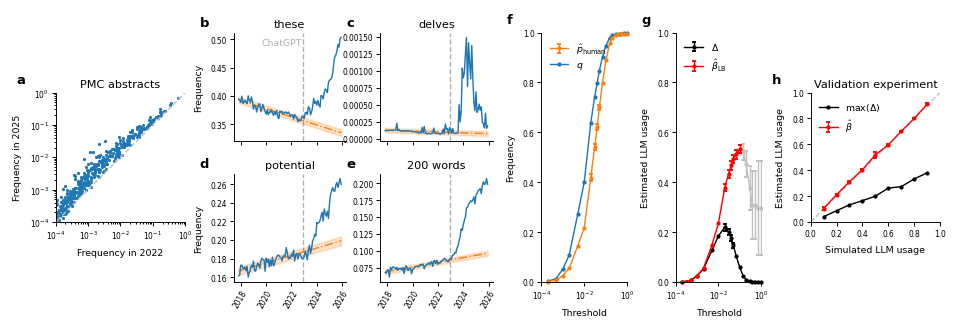

In [26]:
fig = plt.figure(figsize=(7.2, 2.4), constrained_layout=False)


# Main layout:
# [large] [2x2 block] [large] [large] [large]
gs = GridSpec(
    nrows=1,
    ncols=5,
    width_ratios=[1.5, 3, 1, 1, 1.5],
    figure=fig,
    left=0.08,
    right=0.99,
    bottom=0.18,
    top=0.95,
    wspace=0.35,
)

# Large panel 1
ax1 = fig.add_subplot(gs[0])

# Middle 2x2 block
gs_middle = GridSpecFromSubplotSpec(
    2,
    2,
    subplot_spec=gs[1],
    wspace=0.3,
    hspace=0.3,
)

ax2 = fig.add_subplot(gs_middle[0, 0])
ax3 = fig.add_subplot(gs_middle[0, 1])
ax4 = fig.add_subplot(gs_middle[1, 0])
ax5 = fig.add_subplot(gs_middle[1, 1])

# Remaining three large panels
ax6 = fig.add_subplot(gs[2])
ax7 = fig.add_subplot(gs[3])
ax8 = fig.add_subplot(gs[4])


##### CONTENT ######

#### Panel a ####
ax1.scatter(df_22_25["avg_2022"], df_22_25["avg_2025"], s=2)
ax1.plot([0, 1], [0, 1], "--", color="silver")

row = df_22_25[df_22_25["word"] == "underexplored"]
"""
ax1.annotate(
    "under-\nexplored",
    xy=(row["avg_2022"], row["avg_2025"]),
    xytext=(-1, 1),
    textcoords="offset points",
    ha="center",
    va="bottom",
    multialignment="left",
    fontsize=3.5,
)
row = df_22_25[df_22_25["word"] == "underscore"]
ax1.annotate(
    "underscore",
    xy=(row["avg_2022"], row["avg_2025"]),
    xytext=(-1, 1),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=3.5,
)
"""
ax1.set_box_aspect(1)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1e-4, 1)
ax1.set_ylim(1e-4, 1)
ax1.set_xlabel("Frequency in 2022")
ax1.set_ylabel("Frequency in 2025")
ax1.set_title("PMC abstracts")

#### Panels b - e ####
for ax, word in zip([ax2, ax3, ax4, ax5], list(proj_dict.keys())):
    df = proj_dict[word]
    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    if word == "these":
        ax.text(
            x=2022 + (11 / 12) - 0.1,
            y=0.49,
            s="ChatGPT",
            color="black",
            alpha=0.3,
            horizontalalignment="right",
        )  # delve: y=0.0033 these: y=0.5 potential: y=0.268

    sns.lineplot(
        data=df,
        x="time",
        y="projection",
        ax=ax,
        color="tab:orange",
        # alpha=0.5,
        linestyle="-.",
        # label="Expected\nfrequency\n($\\hat{p}_{human}$)",
        label="$\\hat{p}_{\\text{human}}$",
    )
    ax.fill_between(
        df["time"],
        df["projection"] - df["sdev"],
        df["projection"] + df["sdev"],
        alpha=0.2,
        color="tab:orange",
    )
    sns.lineplot(
        data=df,
        x="time",
        y="frequency",
        ax=ax,
        color="tab:blue",
        # label="Observed\nfrequency\n($q$)",
        label="$q$",
    )

    ax.set_xlabel(None)
    if ax in [ax2, ax3]:
        ax.set_xticks(range(2018, 2027, 2))
        ax.set_xticklabels("")
    else:
        ax.set_xticks(range(2018, 2027, 2))
        ax.set_xticklabels(
            range(2018, 2027, 2), rotation=60, ha="right", rotation_mode="anchor"
        )
    if ax in [ax3, ax5]:
        ax.set_ylabel(None)
    else:
        ax.set_ylabel("Frequency")

    if word == "excess_list":
        ax.set_title("200 words")
    else:
        ax.set_title(f"{word}")

    if word == "delve":
        ax.legend()
    else:
        ax.get_legend().remove()

#### Panel f ####
target_year = 2025
se_thr_low = 0.01
se_thr_high = 0.025
f = freqs_cutoffs[freqs_cutoffs["time"] == target_year]
f_filt = freqs_cutoffs_filtered[freqs_cutoffs_filtered["time"] == target_year]

if len(np.where(f_filt["regression se (ds)"] > se_thr_high)[0]) > 0:
    high_error = np.where(f_filt["regression se (ds)"] > se_thr_high)[0][0]
else:
    high_error = len(f_filt)

ax6.errorbar(
    f["cutoff"],
    f["projection"],
    yerr=np.where(
        f["regression se"] > se_thr_low, f["regression se"], np.nan
    ),  # ±1 standard errors
    fmt=".-",  # np.where(yerr >= threshold, yerr, np.nan)
    # ecolor="grey",
    capsize=1.2,
    # label="Expected\nfrequency\n($\\hat{p}_{human}$)",
    label="p",
    clip_on=False,
    markersize=2.5,
    color="tab:orange",
)
ax6.plot(
    f["cutoff"],
    f["frequency"],
    ".-",
    clip_on=False,
    # label="Observed\nfrequency\n($q$)",
    label="q",
    markersize=2.5,
    color="tab:blue",
)
ax6.set_xscale("log")
ax6.set_xlim([1e-4, 1])
ax6.set_ylim([0, 1])
ax6.set_ylabel("Frequency")
ax6.set_xlabel("Threshold")

handles, labels = ax6.get_legend_handles_labels()
order = ["p", "q"]
label_map = {
    "p": "$\\hat{p}_{\\text{human}}$",
    "q": "$q$",
}
handle_dict = dict(zip(labels, handles))
ax6.legend(
    [handle_dict[label] for label in order],
    [label_map[label] for label in order],
    loc="upper left",
)


#### Panel g ####
ax7.errorbar(
    f_filt["cutoff"][high_error - 1 :],
    f_filt["usage estimate"][high_error - 1 :],
    yerr=f_filt["regression se (ds)"][high_error - 1 :],  # ±1 standard errors
    fmt=".-",
    color="silver",
    capsize=1.2,
    markersize=2.5,
    zorder=0.5,
)
ax7.errorbar(
    f_filt["cutoff"],
    f_filt["diff"],
    yerr=np.where(
        f_filt["regression se (delta)"] > se_thr_low,
        f_filt["regression se (delta)"],
        np.nan,
    ),  # ±1 standard errors
    fmt="k.-",
    capsize=1.2,
    label="$\\Delta$",
    clip_on=False,
    markersize=2.5,
)
ax7.errorbar(
    f_filt["cutoff"][:high_error],
    f_filt["usage estimate"][:high_error],
    yerr=np.where(
        f_filt["regression se (ds)"][:high_error] > se_thr_low,
        f_filt["regression se (ds)"][:high_error],
        np.nan,
    ),  # ±1 standard errors
    fmt="r.-",
    capsize=1.2,
    label="$\\hat{\\beta}_{\\text{LB}}$",
    markersize=2.5,
)

ax7.set_xscale("log")
ax7.set_xlim([1e-4, 1.15])
ax7.set_ylim([0, 1])
ax7.set_ylabel("Estimated LLM usage")
ax7.legend(loc="upper left")
ax7.set_xlabel("Threshold")


#### Panel h ####
ax8.plot([0, 1], [0, 1], "--", color="silver")
ax8.errorbar(
    llm_use,
    max_est,
    yerr=sdevs,  # ±1 standard errors
    fmt="r.-",
    capsize=1.2,
    label="$\\hat{\\beta}$",
    markersize=2.5,
)
ax8.plot(llm_use, max_diff, "k.-", label="$\\max(\\Delta)$", markersize=2.5)
ax8.set_box_aspect(1)
ax8.set_xlim([0, 1])
ax8.set_ylim([0, 1])
ax8.set_ylabel("Estimated LLM usage")
ax8.set_xlabel("Simulated LLM usage")
ax8.legend()
ax8.set_title("Validation experiment")

for ax, letter in zip(
    [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8], ["a", "b", "c", "d", "e", "f", "g", "h"]
):
    if letter in ["f", "g"]:
        x = -0.4
        y = 1.08
    else:
        x = -0.3
        y = 1.15
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="top",
    )

# plt.tight_layout()
fig.savefig(
    "methods.pdf",
    format="pdf",
    bbox_inches="tight",
)